## Define models

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from numba import njit



@njit
def model_w_delays(t, y, alpha, delta, CP, b, delta_P, K, cost, pl, T_lysis, T_pili, N, gamma_vec, M):
    gamma_lo = 10**(-12)
    y = y.reshape(2 + 3*M + 2*N*M) #for some reason without this y = [y0,y1,...,yn] becomes y = [[y0],[y1],...,[yn]]
    k_vec = CP * gamma_vec
    k_lo = CP*gamma_lo
    i_scalars = slice(0,2)
    i_B0 = slice(2, 2 + M)
    i_Bp = slice(2 + M, 2 + 2*M)
    i_Bpnp = slice(2 + 2*M, 2 + 2*M + N*M)
    i_Bi = slice(2 + 2*M + N*M, 2 + 2*M + 2*N*M)
    P = y[0]
    Bc = y[1]
    B0 = y[i_B0]
    Bp = y[i_Bp]
    #The pilus and lysis delay states are structured as B[N*i + j] is the jth state of strain i
    Bpnp = y[i_Bpnp]
    Bi = y[i_Bi]



    ##################################
    #Main variables
    ##################################
    C = 1 - (Bc + sum(B0) + sum(Bp) + sum(Bpnp) + sum(Bi))/K 
    dB0dt =  alpha*C*(B0 + pl*(1+cost)*Bp) - np.dot(gamma_vec, Bp)*B0 - delta*B0
    dBpdt = alpha*(1 + cost)*C*(1 - pl)*Bp + N/T_pili*Bpnp[N-1::N] - (k_vec*P)*Bp - delta*Bp #[N-1::N] grabs every Nth element after element M to grab the last delay state for each strain
    dPdt = b*N/T_lysis*sum(Bi[N-1::N]) - delta_P * P  - P*np.dot(k_vec, Bp)
    dPdt += - k_vec[-1]*sum(Bi) #All infected cells are assumed to absorb phage at the same rate as their pili expressing counterparts
    dBcdt = alpha*C*Bc- delta*Bc

    ##################################
    #delay states for conjugative pili
    ##################################
    dBpnpdt = np.zeros(len(Bpnp))
    #iterate through each strain i
    for i in range(M):
        Bpnp_i = Bpnp[i*N : (i+1)*N]
        dBpnp_idt = np.zeros(len(Bpnp_i))
        #iterate over each intermediate state j
        dBpnp_idt[0] = np.dot(gamma_vec, Bp)*B0[i] - (N/T_pili + delta)*Bpnp_i[0]
        for j in range(1, len(Bpnp_i)):
            dBpnp_idt[j] = N/T_pili*Bpnp_i[j-1] - (N/T_pili + delta)*Bpnp_i[j]
            
        dBpnpdt[i*N : (i+1)*N] = dBpnp_idt


    #################################
    #delay states for infection
    #################################
    dBidt = np.zeros(len(Bi))
    #iterate through each strain i
    for i in range(M):
        Bi_i = Bi[i*N : (i+1)*N]
        dBi_idt = np.zeros(len(Bi_i))
        #iterate over each intermediate state j
        dBi_idt[0] = k_vec[i]*Bp[i]*P - (N/T_lysis + delta)*Bi_i[0]
        for j in range(1, len(Bi_i)):
            dBi_idt[j] = N/T_lysis*Bi_i[j-1] - (N/T_lysis + delta)*Bi_i[j]
            
        dBidt[i*N : (i+1)*N] = dBi_idt


    #Assemble the output
    dydt = np.zeros(len(y))
    dydt[i_scalars] = [dPdt, dBcdt]
    dydt[i_B0] = dB0dt
    dydt[i_Bp] = dBpdt
    dydt[i_Bpnp] = dBpnpdt
    dydt[i_Bi] = dBidt

    return dydt
            




## Define parameters

In [2]:
#parameters
alpha = 1.0        # Growth rate of the bacteria w/o the plasmid
CP = 10**(0) #constant of proportionality between the congugation constant and the phage predation constant (due to pilus expression)
delta = 0.1     #Death rate of bacteria
b = 10**2     # Burst size of phage
delta_P = 0.1      # Rate of background death of phage
K = 10**8  #carrying capacity
cost = -0.5 #growth cost of plasmid
pl = 0.001     # Probability of losing the plasmid
N = 5
T_lysis = 0.5
T_pili = 0.5
#Simulation parameters
tf = 3*10**3 #Time to be simulated (in hours)
tEq = 1000



M = 20 #number of different conjugation rates

gamma_vec = np.logspace(-12, -8, num = M)
print(gamma_vec)


[1.00000000e-12 1.62377674e-12 2.63665090e-12 4.28133240e-12
 6.95192796e-12 1.12883789e-11 1.83298071e-11 2.97635144e-11
 4.83293024e-11 7.84759970e-11 1.27427499e-10 2.06913808e-10
 3.35981829e-10 5.45559478e-10 8.85866790e-10 1.43844989e-09
 2.33572147e-09 3.79269019e-09 6.15848211e-09 1.00000000e-08]


## Simulate Figure 2F

262


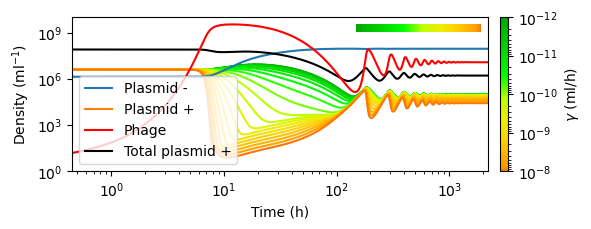

In [4]:
params = [alpha, delta, CP, b, delta_P, K, cost, pl, T_lysis, T_pili, N, gamma_vec, M]


# Initial condition
B00 = np.ones(M)*K/M
Bp0 = np.ones(M)*K/(10*M)
Bpnp0 = np.zeros(N*M)
Bi0 = np.zeros(N*M)
P0 = 0 
Bc0 = 0 #no competitor
scalar_vars0 = [P0, Bc0]

i_scalars = slice(0,2)
i_B0 = slice(2, 2 + M)
i_Bp = slice(2 + M, 2 + 2*M)
i_Bpnp = slice(2 + 2*M, 2 + 2*M + N*M)
i_Bi = slice(2 + 2*M + N*M, 2 + 2*M + 2*N*M)


#Assemble initial condition
y0 = np.empty(2 + 3*M + 2*N*M)
y0[i_scalars] = scalar_vars0
y0[i_B0] = B00
y0[i_Bp] = Bp0
y0[i_Bpnp] = Bpnp0
y0[i_Bi] = Bi0

#run simulation without phage until equilibrium
###################################################

print(len(y0))
t0 = 0
tEq = 1000.0
solEq = solve_ivp(
        model_w_delays,
        [t0, tEq],
        y0,
        args = params,
        dense_output=False,
        method='LSODA', 
        max_step=0.1 
    )


#Add competitor
#####################################
yEq = solEq.y[:, -1].copy()
y0 = yEq
y0[0] = 10
t0 = 0


#Define exctinction events (params are needed because solve_ivp always calls the event functions using them)
##################################################################################
def Bp_extinction_event(t, y, alpha, delta, CP, b, delta_P, K, cost, pl, T_lysis, T_pili, N, gamma_vec, M):
    return sum(y[i_Bp]) - 1
Bp_extinction_event.terminal = True
Bp_extinction_event.direction = -1

def P_extinction_event(t, y, alpha, delta, CP, b, delta_P, K, cost, pl, T_lysis, T_pili, N, gamma_vec, M):
    return y[0] - 1
P_extinction_event.terminal = True
P_extinction_event.direction = -1

def Bc_extinction_event(t, y, alpha, delta, CP, b, delta_P, K, cost, pl, T_lysis, T_pili, N, gamma_vec, M):
    return y[1] - 1
Bc_extinction_event.terminal = True
Bc_extinction_event.direction = -1


extinction_events = [Bp_extinction_event, P_extinction_event, Bc_extinction_event]


#Run simulation loop that halts when extinction events are triggered and restarts with extinct populations set to zero
#####################################
t_all = []
y_all = []
t_span = [t0, tf]
t_eval = np.concatenate(([0], np.logspace(np.log(0.0000001), np.log10(tf), 10**4)))
while t0 < tf:
    t_span = [t0,tf]
    t_eval = [t for t in t_eval if t >= t0]
    sol = solve_ivp(
        model_w_delays,
        t_span,
        y0,
        events=extinction_events,
        args = params,
        dense_output=False,
        method='LSODA', 
        max_step= 1.0
    )




    # Store results
    t_all.extend(sol.t)
    y_all.extend(sol.y.T)
    # Check which event triggered
    triggered = [len(ev) > 0 for ev in sol.t_events]
    y0 = sol.y[:, -1].copy()


    if triggered[0]:  #plasmid extinction
        y0[i_Bp] = 0
        print('plasmid extinct')
    if triggered[1]:  #phage extinction
        y0[0] = 0.0
        
    if triggered[2]:  #competitor extinction
        y0[1] = 0.0

    if not any(triggered):
        break  # no events, done
    else:
        t0 = sol.t[-1]




#store simulation output data
data = np.array(y_all)
t = t_all.copy()




datasets = [data]
times = [t]
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.ticker as mticker
import numpy as np

fig, ax = plt.subplots(figsize=(6.5, 2))

# use gamma directly


cmap_Bp = mcolors.LinearSegmentedColormap.from_list(
    "", plt.colormaps['nipy_spectral'](np.linspace(0.47, 0.81, 256))
)


#plot subpopulations of cells with plasmid
norm = mcolors.LogNorm(vmin=np.min(gamma_vec), vmax=np.max(gamma_vec))
for i in range(len(data.T[i_Bp])):
    color2 = cmap_Bp(norm(gamma_vec[i]))
    ax.plot(t, data.T[2 + M + i], color=color2, lw=1.5)

#plot total of no-plasmid cells
B0_T = sum(data.T[i_B0])
ax.plot(t, B0_T, color = 'C0' )

Bp_T = sum(data.T[i_Bp]) + sum(data.T[i_Bpnp]) + sum(data.T[i_Bi])

ax.plot(t, Bp_T, color = "black")

ax.plot(t, data.T[0], color = "red")

# dummy legend entries for line styles
from matplotlib.lines import Line2D
style_handles = [
    Line2D([0], [0], color='C0', linestyle='-', label='Plasmid -'),
    Line2D([0], [0], color='tab:orange', linestyle='-', label='Plasmid +'),
    Line2D([0], [0], color='red', linestyle='-', label='Phage'),
    Line2D([0], [0], color='black', linestyle='-', label='Total plasmid +')
]

ax.legend(handles=style_handles)

ax.margins(x=0)
ax.set_ylim(1, 10**10)
ax.set_xlim(0.45, 2200)
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel('Density (ml$^{-1}$)')
ax.set_xlabel('Time (h)')
ax.grid(False)




sm_Bp = cm.ScalarMappable(norm=norm, cmap=cmap_Bp)
sm_Bp.set_array([])



cbar = plt.colorbar(sm_Bp, ax=ax, pad=0.025)
cbar.ax.invert_yaxis()

locator = mticker.LogLocator(base=10)
formatter = mticker.LogFormatterMathtext(base=10)


cbar.ax.yaxis.set_major_locator(locator)
cbar.ax.yaxis.set_major_formatter(formatter)


cbar.set_label(r'$\gamma$ (ml/h)')




from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

cax = inset_axes(ax, width="30%", height="5%", loc='upper right')

sm = ScalarMappable(norm=Normalize(vmin=0, vmax=1), cmap=cmap_Bp)
sm.set_array([])

cbar = plt.colorbar(sm, cax=cax, orientation='horizontal')
cbar = plt.colorbar(sm, cax=cax, orientation='horizontal')
cbar.set_ticks([])
cbar.outline.set_visible(False)


plt.savefig('Figure_2F.svg', format = 'svg')

## Calculate Figure 2G (may take several minutes)

Progress: 99.33333333333333%


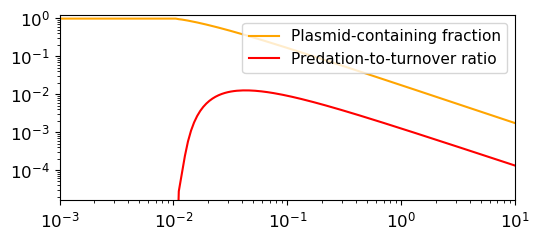

In [12]:
from IPython.display import clear_output

CP_vals = np.logspace(-3, 1, 150) 



B0_final = []
Bp_final = []
P_final = []
p_frac = []
rel_pred = []



for step,CP in enumerate(CP_vals):
    #progress tracker
    clear_output(wait=True)
    print(f"Progress: {step/len(CP_vals)*100}%")

    #Set parameters for point on plot
    k_vec = CP*gamma_vec
    params = [alpha, delta, CP, b, delta_P, K, cost, pl, T_lysis, T_pili, N, gamma_vec, M]

    #initial condition

    B00 = np.ones(M)*K/M
    Bp0 = np.ones(M)*K/(10*M)
    Bpnp0 = np.zeros(N*M)
    Bi0 = np.zeros(N*M)
    scalar_vars0 = [P0, Bc0]
    y0 = np.empty(2 + 3*M + 2*N*M)
    i_scalars = slice(0,2)
    i_B0 = slice(2, 2 + M)
    i_Bp = slice(2 + M, 2 + 2*M)
    i_Bpnp = slice(2 + 2*M, 2 + 2*M + N*M)
    i_Bi = slice(2 + 2*M + N*M, 2 + 2*M + 2*N*M)

    y0[i_scalars] = scalar_vars0
    y0[i_B0] = B00
    y0[i_Bp] = Bp0
    y0[i_Bpnp] = Bpnp0
    y0[i_Bi] = Bi0



    #Calculate equilibrium
    solEq = solve_ivp(
        model_w_delays,
        [0, tEq],
        y0,
        args=params,
        method='LSODA',
        max_step=1.0
    )

    y0 = solEq.y[:, -1].copy()
    y0[0] = 10  # add phage

    # invasion phase
    sol = solve_ivp(
        model_w_delays,
        [0, tf],
        y0,
        args=params,
        method='LSODA',
        max_step=1.0
    )

    data = sol.y.T

    # totals across strains
    B0_total = np.sum(data[:, i_B0], axis=1)
    Bp_total = np.sum(data[:, i_Bp], axis=1)

    B0_final.append(B0_total[-1])
    Bp_final.append(Bp_total[-1])
    p_frac.append(Bp_total[-1]/(B0_total[-1] + Bp_total[-1]))
    Pf = data[-1,0]
    P_final.append(Pf)

    pred = np.dot(data[-1, i_Bp], k_vec)*Pf
    rel_pred.append(pred/(K*delta))


fig, ax1 = plt.subplots(ncols=1, sharey=False, figsize=(5.5,2.5))

# Make plot for Figure 2G
ax1.plot(CP_vals, p_frac, label="Plasmid-containing fraction", color='orange')
ax1.plot(CP_vals, rel_pred, label="Predation-to-turnover ratio", color='red')

ax1.set_xscale("log")
ax1.set_yscale("log")
plt.ylim(10**(-4.8), 1.2) 
plt.xlim(10**(-3), 10)
ax1.grid(False)
ax1.legend(fontsize = 11, loc = "upper right")

ax1.tick_params(axis='both', which='both', labelsize=12)   # label size
#ax1.tick_params(axis='both', which='major', length=6)
#ax1.tick_params(axis='both', which='minor', length=3)

plt.tight_layout()
plt.savefig('Figure_2G.svg', format = 'svg')